In [1]:
from wrapper import BasicEnvironmentRGB, DomainRandomization
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fundamental_variable_discovery import Encoder, Decoder, DoubleAutoencoder
import numpy as np
import torch
import skdim

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
steps = 10000
l1_coeff = 0
env = gym.make('Acrobot-v1', render_mode="rgb_array")
# env = DomainRandomization(env, {"LINK_LENGTH_1": (0.5, 2.0), "LINK_LENGTH_2": (0.5, 2.0)})
env = BasicEnvironmentRGB(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=steps)

In [2]:
obs, _ = env.reset()

In [3]:
samples = random_sample_single_env(env, num_steps=steps)
for i in range(steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [4]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)


In [11]:
losses = []
for i in range(2000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(256)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    reconstruction = decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstruction, obs)
    loss.backward()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())

0
1000


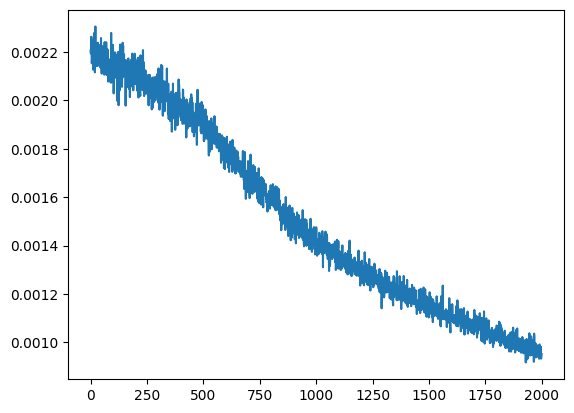

In [12]:
plt.plot(losses)

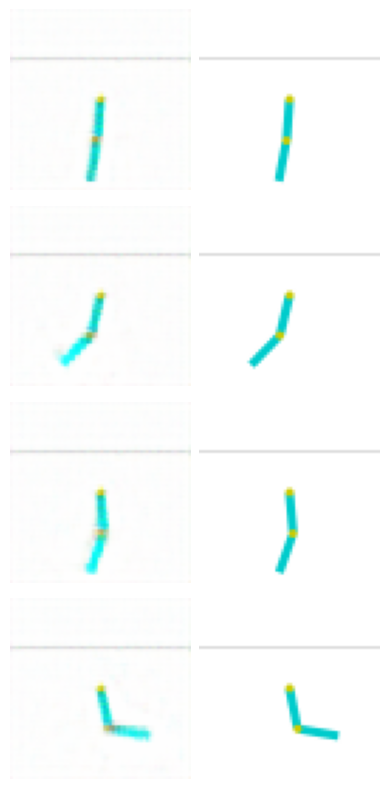

In [13]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [14]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 ).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 5.3037937098337355 +- 0.05670020472765574
Image ID: 6.3968725793858345 +- 0.07293984174147036


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000


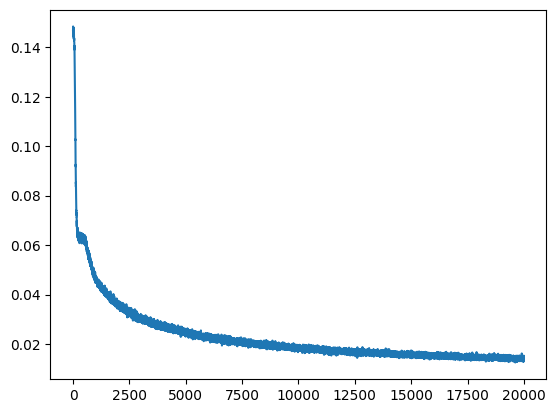

In [10]:
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = DoubleAutoencoder(encoder, decoder, latent_dim, intrinsic_dim).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-5)

losses = []
for i in range(20000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(256)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = double_autoencoder.compute_latent(obs).detach()
    int_ = double_autoencoder.compute_intrinsic(latent)
    latent_reconstruction = double_autoencoder.reconstruct_latent(int_)
    loss = torch.nn.functional.mse_loss(latent, latent_reconstruction)
    loss.backward()
    int_opt.step()
    int_opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

tensor([-0.1405, -0.3552,  0.7539,  ...,  0.4619, -0.1802, -0.5805],
       device='cuda:0')
tensor([-0.1923, -0.4710,  0.3636,  ...,  0.5144, -0.1536, -0.6034],
       device='cuda:0', grad_fn=<SelectBackward0>)


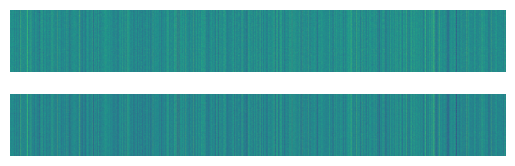

In [ ]:
f, axs = plt.subplots(2)
f.set_figheight(2)
axs[0].axis('off')
im = axs[0].imshow(to_numpy(latent))
axs[1].axis('off')
im = axs[1].imshow(to_numpy(latent_reconstruction))
print(latent[0])
print(latent_reconstruction[0])

In [11]:
# from matplotlib.widgets import Slider
# %matplotlib widget

# def decode(intrinsic):
#     intrinsic_tensor = torch.tensor(intrinsic).cuda()
#     latent = int_decoder(intrinsic_tensor)
#     reconstruction = decoder(latent)
#     reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
#     return reconstruction[:, :, :3], reconstruction[:, :, 3:]

# intrinsic = to_numpy(int_[1])

# plt.figure()
# img = decode(intrinsic)
# f, axs = plt.subplots(1, 2)
# img_handle1 = axs[0].imshow(img[0])
# img_handle2 = axs[1].imshow(img[1])

# plt.subplots_adjust(left=0.25, bottom=0.35)

# slider_axes = []
# sliders = []
# for i in range(5):
#     ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
#     slider_axes.append(ax)
#     slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
#     sliders.append(slider)

# def update(val):
#     for i, slider in enumerate(sliders):
#         intrinsic[i] = slider.val
#     img = decode(intrinsic)
#     img_handle1.set_data(img[0])
#     img_handle2.set_data(img[1])
#     plt.draw()

# for slider in sliders:
#     slider.on_changed(update)

# plt.show()

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000


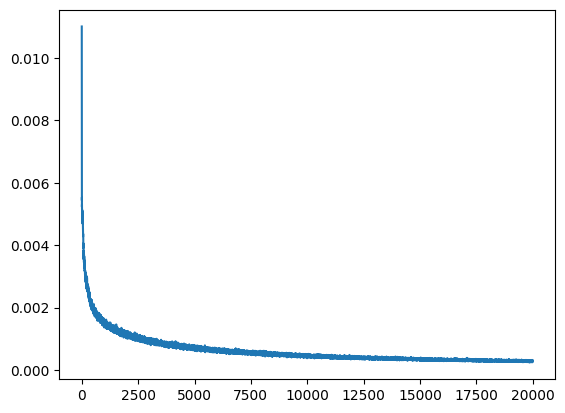

In [11]:
%matplotlib inline
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = DoubleAutoencoder(encoder, decoder, latent_dim, intrinsic_dim).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-5)

losses = []
for i in range(20000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(256)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs)
    reconstruction = double_autoencoder.double_decode(intrinsic)
    loss = torch.nn.functional.mse_loss(reconstruction, obs)
    loss.backward()
    int_opt.step()
    int_opt.zero_grad()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

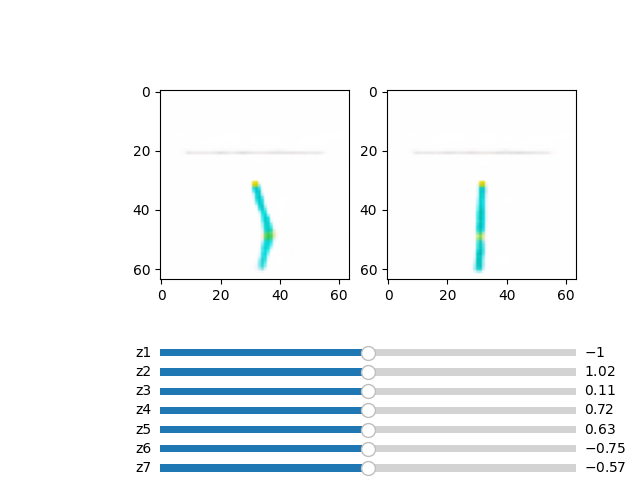

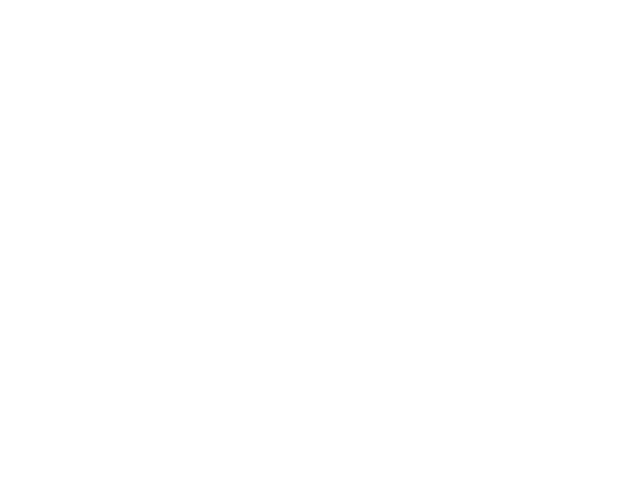

In [ ]:
# from matplotlib.widgets import Slider
# %matplotlib widget

# def decode(intrinsic):
#     intrinsic_tensor = torch.tensor(intrinsic).cuda()
#     latent = int_decoder(intrinsic_tensor)
#     reconstruction = decoder(latent)
#     reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
#     return reconstruction[:, :, :3], reconstruction[:, :, 3:]

# intrinsic = to_numpy(int_[1])

# plt.figure()
# img = decode(intrinsic)
# f, axs = plt.subplots(1, 2)
# img_handle1 = axs[0].imshow(img[0])
# img_handle2 = axs[1].imshow(img[1])

# plt.subplots_adjust(left=0.25, bottom=0.35)

# slider_axes = []
# sliders = []
# for i in range(intrinsic_dim):
#     ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
#     slider_axes.append(ax)
#     slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
#     sliders.append(slider)

# def update(val):
#     for i, slider in enumerate(sliders):
#         intrinsic[i] = slider.val
#     img = decode(intrinsic)
#     img_handle1.set_data(img[0])
#     img_handle2.set_data(img[1])
#     plt.draw()

# for slider in sliders:
#     slider.on_changed(update)

# plt.show()

<Figure size 640x480 with 0 Axes>

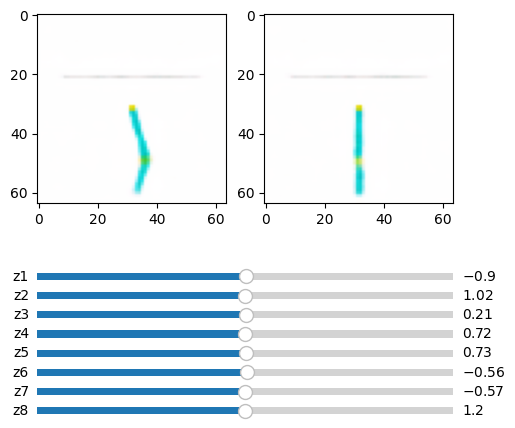

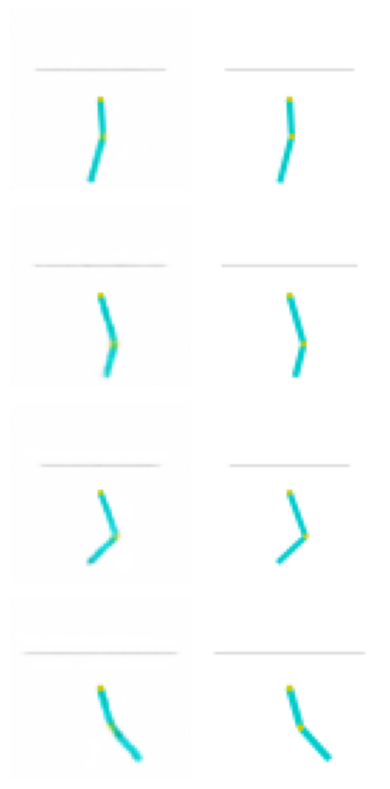

In [14]:
%matplotlib inline
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()